# Analyse factorielle de donnees mixtes (AFDM / FAMD)


Ici, les donnees sont **mixtes** : certaines variables sont qualitatives (`selectivite`, `filiere`, `region`, `statut`), d'autres quantitatives (`capacite`, `pression`, `taux d'acces`, etc.).

En Python, l'analogue le plus naturel d'une MFA appliquee a des donnees mixtes est l'**AFDM / FAMD** (`Factor Analysis of Mixed Data`) du package `prince`. C'est donc cette methode que l'on utilise ici.

In [1]:
import importlib
import os
import subprocess
import sys
from pathlib import Path

for pkg in ["prince"]:
    try:
        importlib.import_module(pkg)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--user", pkg])

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

'c:\\Users\\deler\\Documents\\Insa4A\\Semestre2_4A\\Analyse_De_Donnees\\Projet\\An2DO_4A\\Rendu\\Fichier_Rendu\\Python\\.mplconfig'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import prince

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

## 1. Chargement des donnees



L'objectif n'est pas de tout utiliser, mais de construire un **jeu de variables coherent** avec la methode.

In [ ]:
candidate_paths = [
    Path("../../../data/raw/Parcoursup.csv"),
    Path("An2DO_4A/data/raw/Parcoursup.csv"),
    Path("data/raw/Parcoursup.csv"),
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), candidate_paths[0])
df_raw = pd.read_csv(DATA_PATH, sep=";")

print(f"Chemin : {DATA_PATH.resolve()}")
print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
display(df_raw.head())

Chemin : C:\Users\deler\Documents\Insa4A\Semestre2_4A\Analyse_De_Donnees\Projet\An2DO_4A\data\raw\Parcoursup.csv
Dimensions : 14252 lignes x 118 colonnes


,Session,"Statut de l’établissement de la filière de formation (public, privé…)",Code UAI de l'établissement,Établissement,Code départemental de l’établissement,Département de l’établissement,Région de l’établissement,Académie de l’établissement,Commune de l’établissement,Filière de formation,...,tri,cod_aff_form,Concours communs et banque d'épreuves,Lien de la formation sur la plateforme Parcoursup,Taux d’accès,Part des terminales générales qui étaient en position de recevoir une proposition en phase principale,Part des terminales technologiques qui étaient en position de recevoir une proposition en phase principale,Part des terminales professionnelles qui étaient en position de recevoir une proposition en phase principale,etablissement_id_paysage,composante_id_paysage
0,2025,Public,0692185A,INSTITUT DES SCIENCES ET TECHNIQUES DE LA READ...,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 8e Arrondissement,Certificat de capacité d'Orthoptiste,...,3_Autres formations,28087,Aix-Marseille Université - Site de Marseille T...,https://dossierappel.parcoursup.fr/Candidats/p...,13,93,7,1,NaN,NaN
1,2025,Public,0931827F,Université Paris 8,93,Seine-Saint-Denis,Ile-de-France,Créteil,Saint-Denis,Licence - Langues étrangères appliquées - Parc...,...,1_universités,28100,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,98,57,24,19,NaN,NaN
2,2025,Public,0421573G,IFSI du CH de Roanne,42,Loire,Auvergne-Rhône-Alpes,Lyon,Roanne,D.E Infirmier,...,3_Autres formations,28144,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,40,56,37,7,NaN,NaN
3,2025,Public,0691774D,Université Claude Bernard Lyon 1,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Villeurbanne,Licence - Parcours d'Accès Spécifique Santé (P...,...,1_universités,28178,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,36,99,1,0,NaN,NaN
4,2025,Public,0691774D,Université Claude Bernard Lyon 1,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Villeurbanne,Licence - Parcours d'Accès Spécifique Santé (P...,...,1_universités,28180,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,20,99,1,0,NaN,NaN


## 2. Construction du jeu d'analyse

Dans une AFDM, il faut melanger des variables **qualitatives** et **quantitatives**.

On retient ici quatre blocs de lecture :
- le **contexte institutionnel** : selectivite, type de filiere, region, statut ;
- la **taille** de la formation : capacite et nombre de candidats ;
- la **tension a l'entree** : pression de candidature, taux d'acces, taux de proposition ;
- le **profil des admis** : part de boursiers et part de mentions tres bien.

On applique aussi deux transformations simples :
- `log1p` sur les variables de taille, car elles sont tres asymetriques ;
- un regroupement des regions d'outre-mer dans une meme modalite pour garder une lecture plus stable.

In [5]:
df = df_raw.copy()

numeric_cols = [
    "Capacité de l’établissement par formation",
    "Effectif total des candidats pour une formation",
    "Effectif total des candidats ayant reçu une proposition d’admission de la part de l’établissement",
    "Taux d’accès",
    "% d’admis néo bacheliers boursiers",
    "% d’admis néo bacheliers avec mention Très Bien au bac",
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["pression_candidature"] = (
    df["Effectif total des candidats pour une formation"]
    / df["Capacité de l’établissement par formation"].replace(0, np.nan)
)

df["taux_proposition_calcule"] = (
    100
    * df["Effectif total des candidats ayant reçu une proposition d’admission de la part de l’établissement"]
    / df["Effectif total des candidats pour une formation"].replace(0, np.nan)
)

def regrouper_region(x):
    if pd.isna(x):
        return "Non renseignée"
    outre_mer = {"Guadeloupe", "Martinique", "Guyane", "Mayotte", "Réunion"}
    return "Outre-mer" if x in outre_mer else x

analysis_df = pd.DataFrame({
    "etablissement": df["Établissement"],
    "filiere_detaillee": df["Filière de formation détaillée bis"],
    "selectivite": df["Sélectivité"].fillna("Non renseignée").astype(str),
    "filiere_agregee": df["Filière de formation très agrégée"].fillna("Non renseignée").astype(str),
    "region_groupee": df["Région de l’établissement"].map(regrouper_region).astype(str),
    "statut_etablissement": df["Statut de l’établissement de la filière de formation (public, privé…)"].fillna("Non renseigné").astype(str),
    "log_capacite": np.log1p(df["Capacité de l’établissement par formation"]),
    "log_candidats": np.log1p(df["Effectif total des candidats pour une formation"]),
    "pression_candidature": df["pression_candidature"],
    "taux_acces": df["Taux d’accès"],
    "taux_proposition_calcule": df["taux_proposition_calcule"],
    "part_boursiers": df["% d’admis néo bacheliers boursiers"],
    "part_mention_tb": df["% d’admis néo bacheliers avec mention Très Bien au bac"],
})

active_vars = [
    "selectivite",
    "filiere_agregee",
    "region_groupee",
    "statut_etablissement",
    "log_capacite",
    "log_candidats",
    "pression_candidature",
    "taux_acces",
    "taux_proposition_calcule",
    "part_boursiers",
    "part_mention_tb",
]

quali_vars = ["selectivite", "filiere_agregee", "region_groupee", "statut_etablissement"]
quanti_vars = [v for v in active_vars if v not in quali_vars]

analysis_df = (
    analysis_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=active_vars)
    .reset_index(drop=True)
)

print(f"Jeu d'analyse retenu : {analysis_df.shape[0]} lignes")
print("\nVariables qualitatives actives :")
print(quali_vars)
print("\nVariables quantitatives actives :")
print(quanti_vars)

display(analysis_df[active_vars].head())

Jeu d'analyse retenu : 13074 lignes

Variables qualitatives actives :
['selectivite', 'filiere_agregee', 'region_groupee', 'statut_etablissement']

Variables quantitatives actives :
['log_capacite', 'log_candidats', 'pression_candidature', 'taux_acces', 'taux_proposition_calcule', 'part_boursiers', 'part_mention_tb']


,selectivite,filiere_agregee,region_groupee,statut_etablissement,log_capacite,log_candidats,pression_candidature,taux_acces,taux_proposition_calcule,part_boursiers,part_mention_tb
0,formation sélective,Autre formation,Auvergne-Rhône-Alpes,Public,3.713572,6.842683,23.400000,13.0,12.820513,23.0,31.0
1,formation non sélective,Licence,Ile-de-France,Public,3.496508,5.521461,7.781250,98.0,72.289157,17.0,0.0
2,formation sélective,IFSI,Auvergne-Rhône-Alpes,Public,4.043051,7.934513,49.839286,40.0,32.533142,16.0,3.0
3,formation non sélective,PASS,Auvergne-Rhône-Alpes,Public,5.278115,8.695172,30.630769,36.0,34.622468,13.0,10.0
4,formation non sélective,PASS,Auvergne-Rhône-Alpes,Public,4.330733,8.607582,72.960000,20.0,16.885965,18.0,30.0


### Lecture preparatoire

Avant de lancer l'AFDM, on verifie que les variables retenues ont bien un sens réel.

On cherche notamment a voir si l'on capte deja quelques oppositions plausibles :
- formations selectives contre non selectives ;
- filieres courtes / longues ;
- formations tres tendues contre formations plus accessibles ;
- differences de profil social ou scolaire des admis.

In [6]:
display(analysis_df[quanti_vars].describe().round(2))

for col in quali_vars:
    print(f"\n### {col}")
    display(analysis_df[col].value_counts().rename("effectif").to_frame().head(15))

,log_capacite,log_candidats,pression_candidature,taux_acces,taux_proposition_calcule,part_boursiers,part_mention_tb
count,13074.00,13074.00,13074.00,13074.00,13074.00,13074.00,13074.00
mean,3.52,5.96,20.16,58.30,42.98,22.53,8.50
std,0.85,1.31,31.22,29.37,25.95,17.75,14.72
min,0.69,0.69,0.05,1.00,0.65,0.00,0.00
25%,2.94,5.05,6.12,33.00,21.98,10.00,0.00
50%,3.43,5.92,11.17,58.00,38.38,20.00,3.00
75%,3.89,6.87,22.44,86.00,60.71,32.00,10.00
max,8.13,9.87,841.00,100.00,100.00,100.00,100.00



### selectivite


,effectif
selectivite,
formation sélective,10475
formation non sélective,2599



### filiere_agregee


,effectif
filiere_agregee,
BTS,5341
Licence,2692
Autre formation,1711
CPGE,986
BUT,820
Ecole d'Ingénieur,460
Licence_Las,359
EFTS,195
PASS,192



### region_groupee


,effectif
region_groupee,
Ile-de-France,2527
Auvergne-Rhône-Alpes,1524
Hauts-de-France,1181
Occitanie,1113
Nouvelle Aquitaine,1076
Grand-Est,1072
Provence-Alpes-Côte d'Azur,888
Pays-de-la-Loire,768
Bretagne,676



### statut_etablissement


,effectif
statut_etablissement,
Public,10249
Privé sous contrat d'association,1854
Privé enseignement supérieur,881
Privé hors contrat,90


## 3. Estimation de l'AFDM

L'AFDM construit un espace factoriel unique a partir des deux types de variables.

On commence par regarder les **valeurs propres** et la **part de variance** expliquee. Il ne faut pas attendre ici des pourcentages enormes sur les premiers axes : avec des donnees mixtes et plusieurs variables qualitatives, l'information est naturellement plus espacée

In [7]:
famd = prince.FAMD(n_components=5, random_state=42)
famd = famd.fit(analysis_df[active_vars])

eig = famd.eigenvalues_summary.copy()
coords_rows = famd.row_coordinates(analysis_df[active_vars]).rename(columns=lambda c: f"Dim {c + 1}")
coords_vars = famd.column_coordinates_.rename(columns=lambda c: f"Dim {c + 1}")
contrib_vars = (famd.column_contributions_ * 100).rename(columns=lambda c: f"Dim {c + 1}")
contrib_rows = (famd.row_contributions_ * 100).rename(columns=lambda c: f"Dim {c + 1}")

print("Valeurs propres et part de variance :")
display(eig)

Valeurs propres et part de variance :


,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,4.434,7.04%,7.04%
1,3.877,6.15%,13.19%
2,3.484,5.53%,18.72%
3,2.426,3.85%,22.57%
4,2.286,3.63%,26.20%


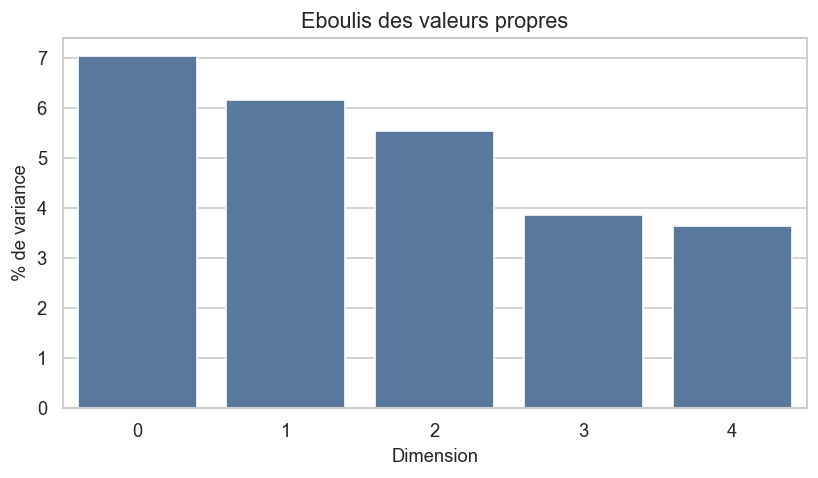

In [8]:
eig_plot = eig.copy()
eig_plot["% of variance"] = eig_plot["% of variance"].str.rstrip("%").astype(float)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=eig_plot.index.astype(str), y="% of variance", data=eig_plot.reset_index(), color="#4C78A8", ax=ax)
ax.set_title("Eboulis des valeurs propres")
ax.set_xlabel("Dimension")
ax.set_ylabel("% de variance")
plt.show()

### Lecture attendue

La bonne question n'est pas seulement "combien explique l'axe 1 ?", mais plutot :
- **quelles variables portent chaque axe** ;
- **quelles oppositions concrètes** apparaissent ;
- si le plan `(1,2)` suffit pour une premiere lecture, ou s'il faut aller voir l'axe 3.


### Contributions des variables sur Dim 1


component,Dim 1
variable,
filiere_agregee,18.67
selectivite,15.65
log_candidats,7.62
log_capacite,7.36
statut_etablissement,5.45
region_groupee,1.52
pression_candidature,1.41
part_mention_tb,1.13
taux_acces,0.13



### Contributions des variables sur Dim 2


component,Dim 2
variable,
taux_proposition_calcule,18.27
taux_acces,15.62
filiere_agregee,11.20
pression_candidature,8.15
log_candidats,7.14
part_mention_tb,4.76
region_groupee,4.28
selectivite,4.17
statut_etablissement,3.45



### Contributions des variables sur Dim 3


component,Dim 3
variable,
filiere_agregee,22.05
statut_etablissement,20.45
part_boursiers,3.52
region_groupee,3.36
pression_candidature,1.81
log_candidats,0.68
part_mention_tb,0.68
selectivite,0.53
taux_acces,0.50


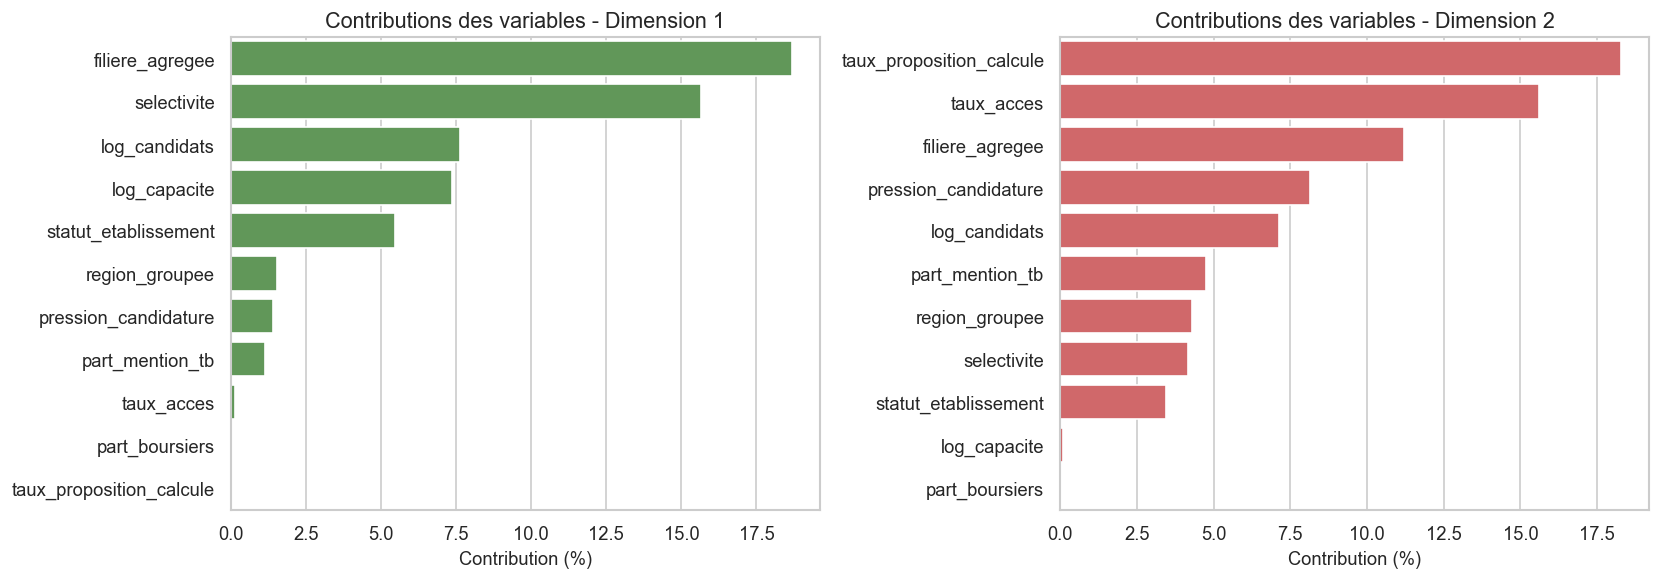


Coordonnees des variables sur les 3 premiers axes :


component,Dim 1,Dim 2,Dim 3
variable,,,
log_capacite,0.326,0.003,0.001
log_candidats,0.338,0.277,0.024
pression_candidature,0.062,0.316,0.063
taux_acces,0.006,0.606,0.017
taux_proposition_calcule,0.000,0.708,0.003
part_boursiers,0.001,0.001,0.122
part_mention_tb,0.050,0.185,0.024
filiere_agregee,0.828,0.434,0.768
region_groupee,0.068,0.166,0.117


In [9]:
for dim in ["Dim 1", "Dim 2", "Dim 3"]:
    print(f"\n### Contributions des variables sur {dim}")
    display(contrib_vars[[dim]].sort_values(dim, ascending=False).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_dim1 = contrib_vars["Dim 1"].sort_values(ascending=False)
top_dim2 = contrib_vars["Dim 2"].sort_values(ascending=False)

sns.barplot(x=top_dim1.values, y=top_dim1.index, color="#59A14F", ax=axes[0])
axes[0].set_title("Contributions des variables - Dimension 1")
axes[0].set_xlabel("Contribution (%)")
axes[0].set_ylabel("")

sns.barplot(x=top_dim2.values, y=top_dim2.index, color="#E15759", ax=axes[1])
axes[1].set_title("Contributions des variables - Dimension 2")
axes[1].set_xlabel("Contribution (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print("\nCoordonnees des variables sur les 3 premiers axes :")
display(coords_vars[["Dim 1", "Dim 2", "Dim 3"]].round(3))

## 4. Lecture du plan principal `(1,2)`

On commence par le plan principal, mais on ne s'y enferme pas.

L'idee est d'identifier des clivages interpretable :
- un axe de **type de formation / selectivite** ;
- un axe de **tension a l'entree / accessibilite** ;
- et, si besoin, un axe 3 plus fin sur les contextes regionaux ou statutaires.

Barycentres par filiere agregee (Dimensions 1 et 2) :


,Dim 1,Dim 2
filiere_agregee,,
EFTS,-3.010,-0.940
BTS,-1.440,-0.027
Autre formation,-1.129,0.923
Ecole d'Ingénieur,-1.094,-1.711
Ecole de Commerce,-0.242,-0.876
CPGE,0.214,2.126
BUT,0.429,1.363
IFSI,1.150,3.397
Licence,2.876,-1.734



Barycentres par selectivite (Dimensions 1 et 2) :


,Dim 1,Dim 2
selectivite,,
formation non sélective,3.524,-1.592
formation sélective,-0.874,0.395


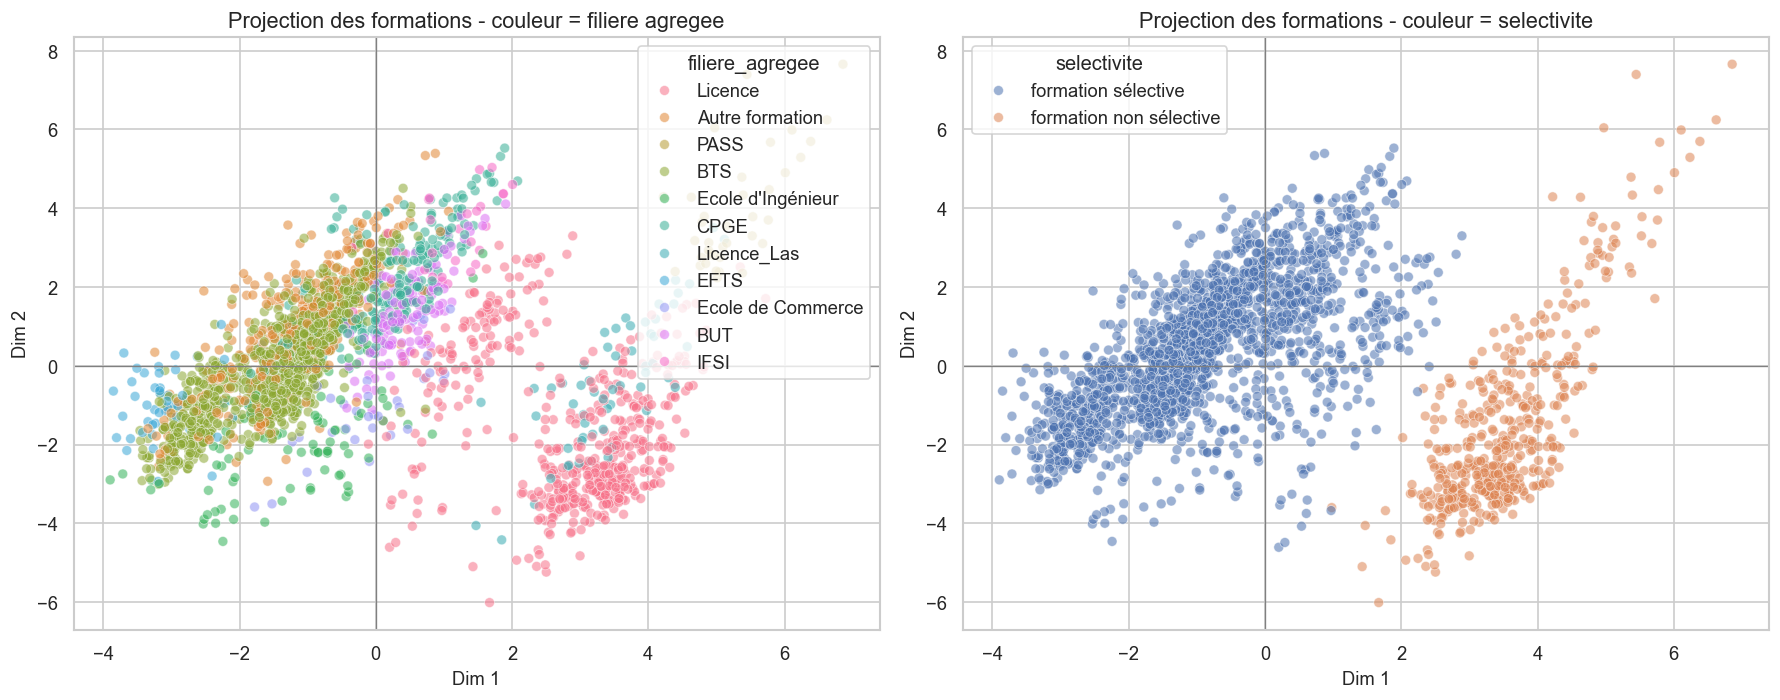

In [10]:
group_projection = pd.concat(
    [analysis_df[["filiere_agregee", "selectivite", "region_groupee", "statut_etablissement"]], coords_rows],
    axis=1,
)

print("Barycentres par filiere agregee (Dimensions 1 et 2) :")
display(group_projection.groupby("filiere_agregee")[["Dim 1", "Dim 2"]].mean().sort_values("Dim 1").round(3))

print("\nBarycentres par selectivite (Dimensions 1 et 2) :")
display(group_projection.groupby("selectivite")[["Dim 1", "Dim 2"]].mean().round(3))

sample_plot = group_projection.sample(min(2500, len(group_projection)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=sample_plot,
    x="Dim 1",
    y="Dim 2",
    hue="filiere_agregee",
    alpha=0.55,
    s=35,
    ax=axes[0],
)
axes[0].set_title("Projection des formations - couleur = filiere agregee")

sns.scatterplot(
    data=sample_plot,
    x="Dim 1",
    y="Dim 2",
    hue="selectivite",
    alpha=0.55,
    s=35,
    ax=axes[1],
)
axes[1].set_title("Projection des formations - couleur = selectivite")

for ax in axes:
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.axvline(0, color="grey", linewidth=0.8)

plt.tight_layout()
plt.show()

### Interpretation 

On voit des clustering sur les fillières ainsique des clustering entre formations sélectives et non-sélectives se former.



In [11]:
top_rows_dim1 = pd.concat(
    [
        analysis_df[["etablissement", "filiere_detaillee", "filiere_agregee", "selectivite", "region_groupee"]],
        coords_rows[["Dim 1"]],
        contrib_rows[["Dim 1"]].rename(columns={"Dim 1": "Contribution Dim 1"}),
    ],
    axis=1,
).sort_values("Dim 1", ascending=False)

top_rows_dim2 = pd.concat(
    [
        analysis_df[["etablissement", "filiere_detaillee", "filiere_agregee", "selectivite", "region_groupee"]],
        coords_rows[["Dim 2"]],
        contrib_rows[["Dim 2"]].rename(columns={"Dim 2": "Contribution Dim 2"}),
    ],
    axis=1,
).sort_values("Dim 2", ascending=False)

print("Observations les plus a droite sur l'axe 1 :")
display(top_rows_dim1.head(10).round(3))

print("\nObservations les plus hautes sur l'axe 2 :")
display(top_rows_dim2.head(10).round(3))

Observations les plus a droite sur l'axe 1 :


,etablissement,filiere_detaillee,filiere_agregee,selectivite,region_groupee,Dim 1,Contribution Dim 1
4515,Université Sorbonne Paris Nord - Antenne de Bo...,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,7.818,0.101
12457,Université Sorbonne Paris Nord - Antenne de Bo...,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,7.795,0.101
4793,Université Paris Cité,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,7.285,0.088
40,Université Sorbonne Paris Nord - Antenne de Bo...,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,7.218,0.086
5036,Université Paris Cité,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,6.896,0.079
2592,Université de Bourgogne Europe (ex UB) - site ...,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Bourgogne-Franche-Comté,6.866,0.075
8703,Université Paris Cité,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,6.856,0.078
8450,Université Sorbonne Paris Nord - Antenne de Bo...,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,6.686,0.074
2585,Ecole Universitaire de premier cycle - Campus ...,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,6.681,0.074
4791,Université Paris Cité,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,6.621,0.073



Observations les plus hautes sur l'axe 2 :


,etablissement,filiere_detaillee,filiere_agregee,selectivite,region_groupee,Dim 2,Contribution Dim 2
2592,Université de Bourgogne Europe (ex UB) - site ...,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Bourgogne-Franche-Comté,11.424,0.278
12457,Université Sorbonne Paris Nord - Antenne de Bo...,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,11.079,0.262
4515,Université Sorbonne Paris Nord - Antenne de Bo...,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,10.754,0.248
40,Université Sorbonne Paris Nord - Antenne de Bo...,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,9.721,0.204
4793,Université Paris Cité,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,8.674,0.164
8703,Université Paris Cité,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,7.657,0.129
8450,Université Sorbonne Paris Nord - Antenne de Bo...,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,7.479,0.123
5036,Université Paris Cité,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,7.475,0.123
9482,Université de Bourgogne Europe (ex UB) - site ...,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Bourgogne-Franche-Comté,7.397,0.120
2585,Ecole Universitaire de premier cycle - Campus ...,Parcours d'Accès Spécifique Santé (PASS),PASS,formation non sélective,Ile-de-France,7.356,0.119


## 5. Aller au-dela d'un plan axe1/axe2

Il est souvent utile d'aller lire un axe supplementaire.

Ici, on regarde surtout la **dimension 3** pour verifier si elle fait apparaitre une structure moins visible dans le plan principal, par exemple un effet de **statut d'etablissement** ou de **territoire**.

Barycentres regionaux sur la dimension 3 :


,Dim 3
region_groupee,
Outre-mer,-1.359
Centre,-1.130
Grand-Est,-0.854
Corse,-0.567
Occitanie,-0.543
Bourgogne-Franche-Comté,-0.296
Nouvelle Aquitaine,-0.170
Provence-Alpes-Côte d'Azur,-0.078
Hauts-de-France,0.042



Barycentres par statut d'etablissement sur la dimension 3 :


,Dim 3
statut_etablissement,
Privé sous contrat d'association,-0.445
Public,-0.427
Privé hors contrat,0.387
Privé enseignement supérieur,5.863


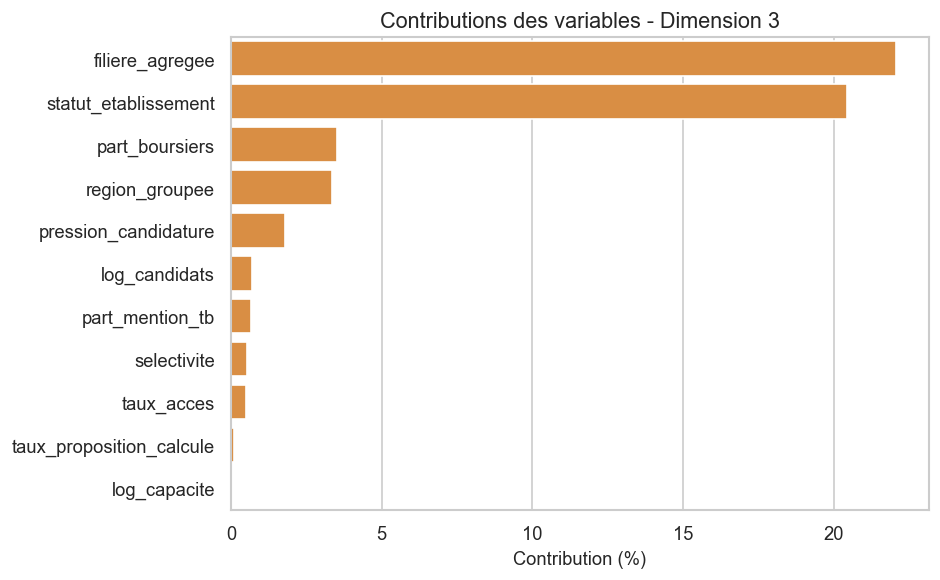

In [12]:
print("Barycentres regionaux sur la dimension 3 :")
display(group_projection.groupby("region_groupee")[["Dim 3"]].mean().sort_values("Dim 3").round(3))

print("\nBarycentres par statut d'etablissement sur la dimension 3 :")
display(group_projection.groupby("statut_etablissement")[["Dim 3"]].mean().sort_values("Dim 3").round(3))

fig, ax = plt.subplots(figsize=(8, 5))
top_dim3 = contrib_vars["Dim 3"].sort_values(ascending=False)
sns.barplot(x=top_dim3.values, y=top_dim3.index, color="#F28E2B", ax=ax)
ax.set_title("Contributions des variables - Dimension 3")
ax.set_xlabel("Contribution (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 6. Synthese finale

Cette AFDM doit etre lue comme une **cartographie mixte des formations Parcoursup**.

Points a retenir apres execution du notebook :
1. l'axe 1 oppose souvent des types de formations et des niveaux de selectivite differents ;
2. l'axe 2 porte davantage la question de la tension a l'entree et de l'accessibilite ;
3. l'axe 3 peut raffiner la lecture avec un effet de statut ou de contexte regional ;

On construit quelques regroupements simples pour enrichir la lecture factorielle:

Barycentres des groupes d'etablissements :


,Dim 1,Dim 2,Dim 3
groupe_etablissement,,,
Autres etablissements,-1.108,0.219,-0.525
Prive enseignement superieur,-0.311,-2.162,5.863
Ile-de-France,1.034,1.584,0.274
Non selectif,3.438,-1.805,-0.841


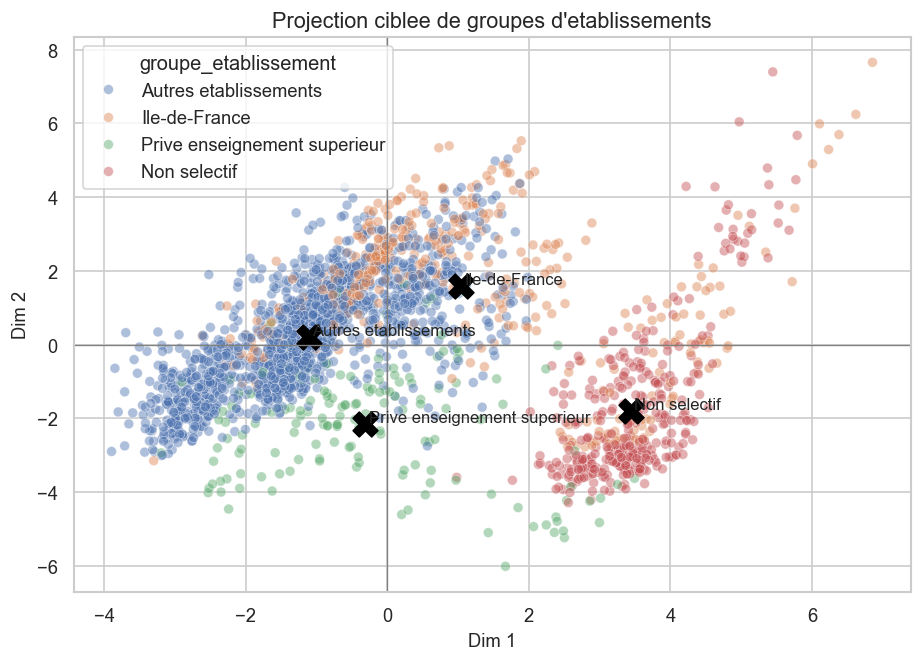

In [ ]:


projection_df = pd.concat(
    [
        analysis_df[
            [
                "etablissement",
                "filiere_agregee",
                "region_groupee",
                "statut_etablissement",
                "selectivite",
            ]
        ],
        coords_rows[["Dim 1", "Dim 2", "Dim 3"]],
    ],
    axis=1,
)

def groupe_etablissement(row):
    if row["statut_etablissement"] == "Privé enseignement supérieur":
        return "Prive enseignement superieur"
    if row["region_groupee"] == "Ile-de-France":
        return "Ile-de-France"
    if row["selectivite"] == "formation non sélective":
        return "Non selectif"
    return "Autres etablissements"

projection_df["groupe_etablissement"] = projection_df.apply(groupe_etablissement, axis=1)

barycentres_groupes = (
    projection_df
    .groupby("groupe_etablissement")[["Dim 1", "Dim 2", "Dim 3"]]
    .mean()
    .sort_values("Dim 1")
    .round(3)
)

print("Barycentres des groupes d'etablissements :")
display(barycentres_groupes)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=projection_df.sample(min(2500, len(projection_df)), random_state=42),
    x="Dim 1",
    y="Dim 2",
    hue="groupe_etablissement",
    alpha=0.45,
    s=35,
    ax=ax,
)

for group_name, row in barycentres_groupes.iterrows():
    ax.scatter(row["Dim 1"], row["Dim 2"], s=220, marker="X", color="black")
    ax.text(row["Dim 1"] + 0.05, row["Dim 2"] + 0.05, group_name, fontsize=10)

ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_title("Projection ciblee de groupes d'etablissements")
plt.show()


Classification sur les coordonnees factorielles

On utilise ici les 5 premieres dimensions de l'AFDM.


Scores de silhouette :


,silhouette
2,0.297
3,0.345
4,0.295
5,0.311
6,0.333
7,0.308


Nombre de classes retenu : 3
Effectifs par cluster :


,effectif
cluster,
0,2630
1,9552
2,892


Profils moyens par cluster sur les axes 1 et 2 :


,Dim 1,Dim 2,Dim 3
cluster,,,
0,3.499,-1.577,-0.505
1,-0.890,0.579,-0.416
2,-0.786,-1.551,5.949


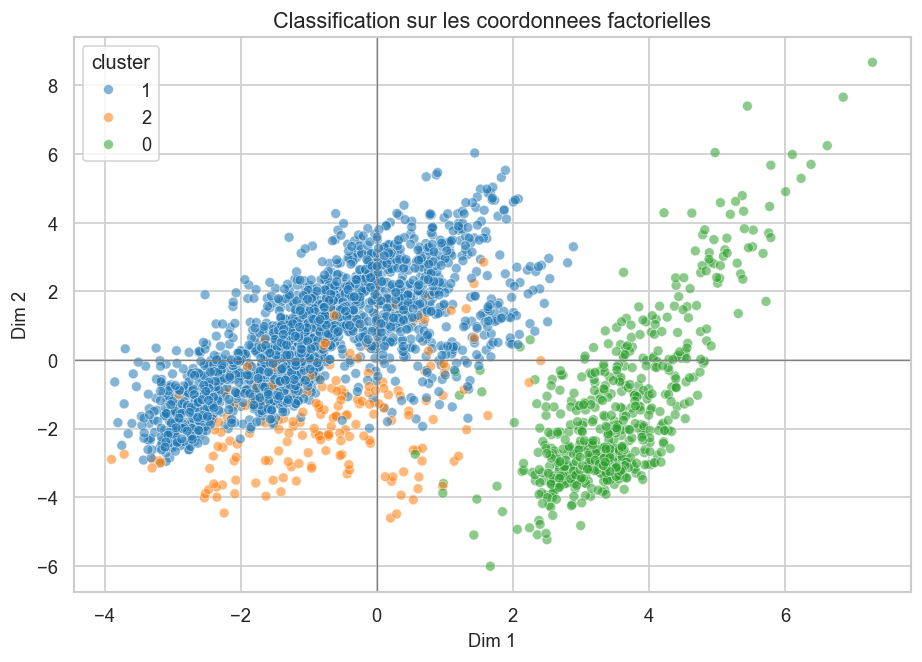

In [ ]:


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

coords_clustering = coords_rows[[f"Dim {i}" for i in range(1, 6)]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(coords_clustering)

scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

print("Scores de silhouette :")
display(pd.Series(scores, name="silhouette").round(3).to_frame())

best_k = max(scores, key=scores.get)
print(f"Nombre de classes retenu : {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)

classification_df = pd.concat(
    [
        analysis_df[
            [
                "etablissement",
                "filiere_detaillee",
                "filiere_agregee",
                "selectivite",
                "region_groupee",
            ]
        ],
        coords_rows,
    ],
    axis=1,
)

classification_df["cluster"] = clusters.astype(str)

print("Effectifs par cluster :")
display(classification_df["cluster"].value_counts().sort_index().rename("effectif").to_frame())

print("Profils moyens par cluster sur les axes 1 et 2 :")
display(
    classification_df
    .groupby("cluster")[["Dim 1", "Dim 2", "Dim 3"]]
    .mean()
    .round(3)
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=classification_df.sample(min(3000, len(classification_df)), random_state=42),
    x="Dim 1",
    y="Dim 2",
    hue="cluster",
    palette="tab10",
    alpha=0.55,
    s=35,
    ax=ax,
)
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_title("Classification sur les coordonnees factorielles")
plt.show()


On resume chaque classe par ses filieres et niveaux de selectivite dominants.

In [ ]:


print("Filieres dominantes par cluster :")
for c in sorted(classification_df["cluster"].unique()):
    print(f"\n### Cluster {c}")
    display(
        classification_df[classification_df["cluster"] == c]["filiere_agregee"]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
        .rename("%")
        .to_frame()
        .head(8)
    )

print("Selectivite dominante par cluster :")
display(
    pd.crosstab(
        classification_df["cluster"],
        classification_df["selectivite"],
        normalize="index"
    ).mul(100).round(1)
)


Filieres dominantes par cluster :

### Cluster 0


,%
filiere_agregee,
Licence,79.0
Licence_Las,13.7
PASS,7.3



### Cluster 1


,%
filiere_agregee,
BTS,55.5
Autre formation,17.1
CPGE,10.3
BUT,8.6
Licence,5.3
EFTS,1.6
IFSI,1.5
Ecole d'Ingénieur,0.0



### Cluster 2


,%
filiere_agregee,
Ecole d'Ingénieur,51.5
Ecole de Commerce,18.4
Licence,11.8
Autre formation,8.7
BTS,4.7
EFTS,4.3
IFSI,0.7


Selectivite dominante par cluster :


selectivite,formation non sélective,formation sélective
cluster,,
0,98.7,1.3
1,0.0,100.0
2,0.2,99.8


CAH sur les coordonnees factorielles de l'AFDM / MFA

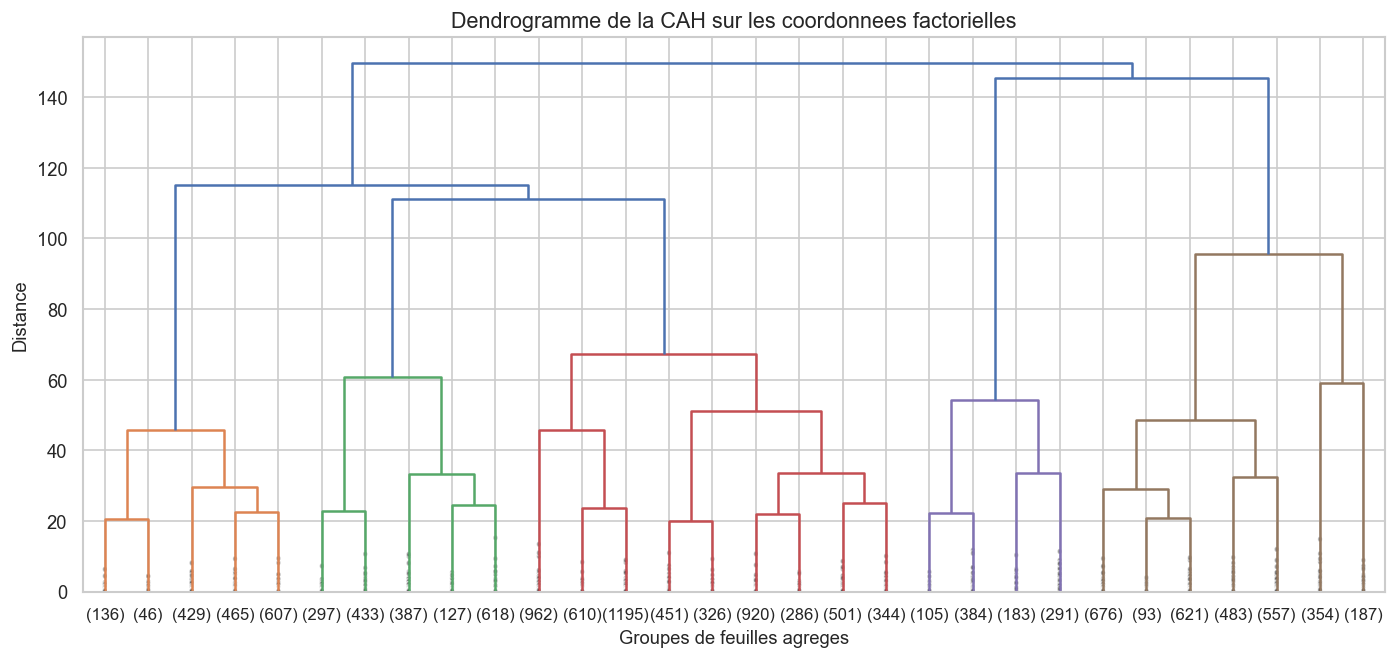

Nombre de classes retenu : 4

Effectifs par classe :


,effectif
cluster_cah,
1,1683
2,7457
3,963
4,2971



Barycentres des classes sur les axes factoriels :


,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5
cluster_cah,,,,,
1,-2.480,-1.120,-0.485,-2.014,0.851
2,-0.661,0.973,-0.392,0.372,-0.329
3,-0.302,-1.886,5.686,0.704,-0.266
4,3.162,-1.197,-0.583,-0.020,0.430



Repartition des filieres par classe (%) :


filiere_agregee,Autre formation,BTS,BUT,CPGE,EFTS,Ecole d'Ingénieur,Ecole de Commerce,IFSI,Licence,Licence_Las,PASS
cluster_cah,,,,,,,,,,,
1,5.7,82.5,0.0,0.2,11.1,0.5,0.0,0.0,0.0,0.0,0.0
2,20.5,52.2,10.4,13.2,0.1,0.0,0.0,2.0,1.5,0.0,0.0
3,8.1,4.6,0.0,0.0,0.0,46.9,17.0,0.6,22.3,0.4,0.0
4,0.2,0.5,1.4,0.0,0.0,0.0,0.0,0.0,79.6,11.8,6.5


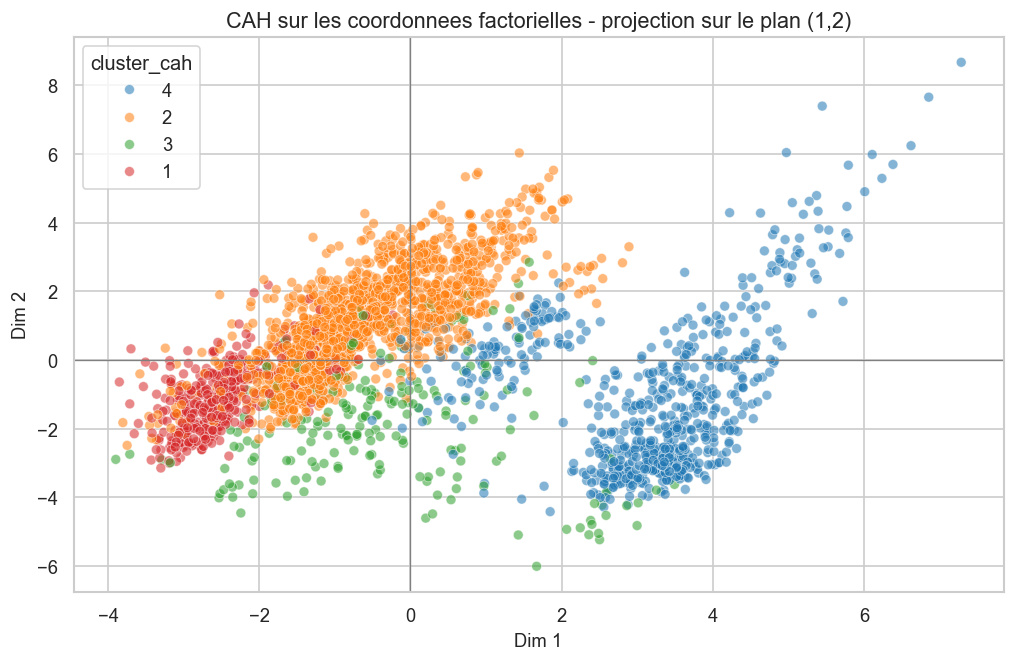

In [ ]:



from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler

# On retient ici les 5 premieres dimensions factorielles.
X_cah = coords_rows[[f"Dim {i}" for i in range(1, 6)]].copy()

# Standardisation par prudence avant la classification.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cah)

# CAH avec methode de Ward.
Z = linkage(X_scaled, method="ward")

# Dendrogramme
plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=0,
    leaf_font_size=10,
    show_contracted=True,
)
plt.title("Dendrogramme de la CAH sur les coordonnees factorielles")
plt.xlabel("Groupes de feuilles agreges")
plt.ylabel("Distance")
plt.show()

# Decoupage en classes
n_classes = 4
clusters_cah = fcluster(Z, t=n_classes, criterion="maxclust")

# Tableau final avec les classes
cah_df = pd.concat(
    [
        analysis_df[
            [
                "etablissement",
                "filiere_detaillee",
                "filiere_agregee",
                "selectivite",
                "region_groupee",
                "statut_etablissement",
            ]
        ],
        coords_rows[[f"Dim {i}" for i in range(1, 6)]],
    ],
    axis=1,
)

cah_df["cluster_cah"] = clusters_cah.astype(str)

print(f"Nombre de classes retenu : {n_classes}")
print("\nEffectifs par classe :")
display(cah_df["cluster_cah"].value_counts().sort_index().rename("effectif").to_frame())

print("\nBarycentres des classes sur les axes factoriels :")
display(
    cah_df.groupby("cluster_cah")[[f"Dim {i}" for i in range(1, 6)]]
    .mean()
    .round(3)
)

print("\nRepartition des filieres par classe (%) :")
display(
    pd.crosstab(cah_df["cluster_cah"], cah_df["filiere_agregee"], normalize="index")
    .mul(100)
    .round(1)
)

# Projection sur le plan factoriel 1-2
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cah_df.sample(min(3000, len(cah_df)), random_state=42),
    x="Dim 1",
    y="Dim 2",
    hue="cluster_cah",
    palette="tab10",
    alpha=0.55,
    s=35,
)
plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.title("CAH sur les coordonnees factorielles - projection sur le plan (1,2)")
plt.show()
# 